# Use Case #2: Intelligent Research & Data Analysis with LangGraph (Agentic RAG)

## How BigCompany Inc. Built a Smart Internal Knowledge Assistant

**The #2 use case for LangGraph in 2026 — 24.4% of all AI agent deployments.**

## The Problem: BigCompany Inc. Can't Find Answers in Their Own Documents

**BigCompany Inc.** has grown rapidly. They now have thousands of internal documents — HR policies, engineering guidelines, product specifications, onboarding manuals, compliance rules, and more.

The problem? **Nobody can find anything.**

Here's what happens every day:

- A new employee asks: *"What is the remote work policy?"* → They spend **30 minutes** searching through shared folders.
- An engineer asks: *"What are the security requirements for deploying a new service?"* → They post in Slack and wait **2 hours** for someone to reply.
- A manager asks: *"What is our policy on conference travel reimbursement?"* → They email HR and wait **a full day** for a response.

The CEO is frustrated:

> *"We have all the answers written down already! Our employees just can't find them. We need an AI assistant that can search our documents and give accurate answers — instantly."*

The engineering team considers building a basic RAG (Retrieval-Augmented Generation) system. But the CTO raises a critical concern:

> *"I've seen basic RAG systems. Sometimes they retrieve the wrong documents and then confidently give wrong answers. We need something smarter — something that checks its own work."*

The team decides to build an **Agentic RAG** system with **LangGraph** — a smart assistant that doesn't just search and answer, but also **grades its own search results** and **rewrites its search queries** when the first attempt isn't good enough.

## What is RAG? (Quick Refresher)

Before we dive into the solution, let's make sure we understand **RAG** — Retrieval-Augmented Generation.

The basic idea is simple:

1. **You have documents** — company policies, manuals, reports, etc.
2. **A user asks a question** — "What is the remote work policy?"
3. **The system retrieves** the most relevant documents from your collection.
4. **The LLM generates** an answer based on those retrieved documents.

This is how you make an LLM answer questions about **your specific data**, rather than just its general training knowledge.

### The Problem with Basic RAG

Basic RAG follows a **one-shot pipeline**: retrieve → generate → done.

But what if the retrieved documents aren't actually relevant to the question? The LLM will still try to generate an answer — and it might **hallucinate** (make up information that sounds right but isn't).

| Scenario | Basic RAG | Agentic RAG |
|----------|-----------|-------------|
| Retrieved documents are relevant | Works great | Works great |
| Retrieved documents are irrelevant | **Generates a wrong answer anyway** | **Detects the problem, rewrites the query, and tries again** |
| Question is ambiguous | **Retrieves random documents** | **Rewrites the question to be more specific** |
| Answer contains hallucinations | **No way to detect** | **Can check if the answer is grounded in the documents** |

## What is Agentic RAG? And Why LangGraph?

**Agentic RAG** replaces the simple one-shot pipeline with an **intelligent loop** that includes self-correction. The key idea: **the agent checks its own work before giving an answer.**

The pattern we'll implement is called **Corrective RAG (CRAG)**. Here's how it works:

```
User asks a question
        │
        ▼
┌──────────────┐
│   RETRIEVE   │ ◄── Search the knowledge base
│  documents   │     for relevant documents
└──────┬───────┘
       │
       ▼
┌──────────────┐
│    GRADE     │ ◄── An LLM checks: "Are these
│  documents   │     documents actually relevant?"
└──────┬───────┘
       │
  ┌────┴─────┐
  │ Decision │
  └────┬─────┘
       │
  ┌────┴────────┐
  │             │
  ▼             ▼
All docs      Some docs
relevant?     irrelevant?
  │             │
  ▼             ▼
┌────────┐  ┌──────────────┐
│GENERATE│  │ REWRITE the  │
│ answer │  │ question and │
└───┬────┘  │  TRY AGAIN   │
    │       └──────┬───────┘
    │              │
    ▼              └──► Back to RETRIEVE
  ┌─────┐
  │ END │
  └─────┘
```

### Why LangGraph is Perfect for This

This pattern requires **loops** — if the documents are bad, go back and try again. Traditional pipelines can't do loops. LangGraph can, because it uses a **graph** where:

- **Nodes** are steps (retrieve, grade, generate, rewrite).
- **Edges** connect the steps.
- **Conditional edges** make decisions ("Are the documents relevant?").
- **Cycles** allow the agent to loop back and retry.

### Simple Analogy

> Think of Agentic RAG like a **research librarian** who doesn't just grab the first book off the shelf. They check if the book is actually relevant to your question, and if it isn't, they try a different search strategy — and they keep going until they find what you actually need.

## Let's Build It! Step by Step

Now let's build BigCompany Inc.'s internal knowledge assistant, one step at a time.

We'll implement the **Corrective RAG (CRAG)** pattern — the most practical and beginner-friendly Agentic RAG pattern.

### Step 0: Install the Required Packages

We need these packages:
- **`langgraph`** — the framework for building our agent's workflow graph.
- **`langchain-openai`** — to connect to OpenAI's models (for the LLM and for embeddings).
- **`langchain`** — provides prompts, output parsers, and other core utilities.

In [1]:
# Install packages (run this once)
#!pip install -U langgraph langchain-openai langchain

### Step 1: Load Environment Variables

Our system needs an **OpenAI API key** for two things:
1. **Embeddings** — to convert text into numbers so we can do similarity search.
2. **LLM calls** — to grade documents, rewrite queries, and generate answers.

In [2]:
import os
from dotenv import load_dotenv

load_dotenv()

OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY")

if OPENAI_API_KEY:
    print("OpenAI API Key loaded successfully!")
else:
    print("WARNING: No OpenAI API Key found. Please set it in your .env file.")

OpenAI API Key loaded successfully!


### Step 2: Create BigCompany Inc.'s Knowledge Base

In a real company, documents would come from a database, Confluence, Google Drive, etc. For this demo, we'll create a small set of company documents manually using LangChain's `Document` class.

Each document has:
- **`page_content`** — the actual text content.
- **`metadata`** — extra information about the document (like its source or category).

We'll create documents covering different topics at BigCompany Inc. to simulate a realistic knowledge base.

In [3]:
from langchain_core.documents import Document

# ============================================================
# BigCompany Inc.'s Internal Knowledge Base
# ============================================================

company_documents = [
    # --- HR Policies ---
    Document(
        page_content=(
            "BigCompany Inc. Remote Work Policy: Employees may work remotely up to "
            "3 days per week. All employees must be in the office on Tuesdays and "
            "Thursdays for team collaboration days. Remote work requests must be "
            "approved by the direct manager. Employees working remotely must be "
            "available on Slack during core hours (10 AM - 4 PM local time)."
        ),
        metadata={"source": "hr_handbook", "topic": "remote_work"},
    ),
    Document(
        page_content=(
            "BigCompany Inc. Vacation Policy: Full-time employees receive 20 days "
            "of paid time off (PTO) per year. PTO requests must be submitted at "
            "least 2 weeks in advance through the HR portal. Unused PTO can be "
            "carried over up to 5 days into the next year. Managers must approve "
            "all PTO requests within 3 business days."
        ),
        metadata={"source": "hr_handbook", "topic": "vacation"},
    ),
    Document(
        page_content=(
            "BigCompany Inc. Travel Reimbursement Policy: Employees traveling for "
            "business purposes can expense flights (economy class), hotels (up to "
            "$200/night), meals (up to $75/day), and ground transportation. All "
            "expenses must be submitted within 30 days of travel with receipts "
            "attached. Conference attendance requires pre-approval from department "
            "heads. The annual conference budget per employee is $3,000."
        ),
        metadata={"source": "finance_guidelines", "topic": "travel"},
    ),
    # --- Engineering Guidelines ---
    Document(
        page_content=(
            "BigCompany Inc. Code Review Policy: All code changes must be reviewed "
            "by at least one other engineer before merging. Pull requests should be "
            "reviewed within 24 hours. The reviewer must check for correctness, "
            "test coverage, security vulnerabilities, and adherence to the team "
            "style guide. Automated tests must pass before a PR can be merged."
        ),
        metadata={"source": "engineering_handbook", "topic": "code_review"},
    ),
    Document(
        page_content=(
            "BigCompany Inc. Deployment Security Requirements: All new services "
            "must pass a security review before deployment to production. Services "
            "must use HTTPS for all communications, implement authentication via "
            "the company SSO system, log all access attempts, and encrypt "
            "sensitive data at rest using AES-256. Database credentials must be "
            "stored in the company vault service, never in code or config files."
        ),
        metadata={"source": "engineering_handbook", "topic": "security"},
    ),
    # --- Product Information ---
    Document(
        page_content=(
            "BigCompany Inc. Product Roadmap Q1 2026: The team is focused on three "
            "main initiatives: (1) Launching the mobile app v2.0 with offline "
            "support, (2) Migrating the payment system to the new provider by "
            "March, and (3) Implementing AI-powered search across all products. "
            "The mobile app launch is the highest priority."
        ),
        metadata={"source": "product_docs", "topic": "roadmap"},
    ),
    # --- Onboarding ---
    Document(
        page_content=(
            "BigCompany Inc. New Employee Onboarding: During your first week, you "
            "will receive your laptop and access credentials, complete mandatory "
            "security training, meet with your manager and team members, set up "
            "your development environment using the setup guide at "
            "docs.bigcompany.com/setup, and attend the company culture "
            "orientation session on Friday."
        ),
        metadata={"source": "onboarding_guide", "topic": "onboarding"},
    ),
]

print(f"BigCompany Inc. knowledge base created!")
print(f"Total documents: {len(company_documents)}")
print(f"\nTopics covered:")
for doc in company_documents:
    print(f"  - {doc.metadata['topic']} (from {doc.metadata['source']})")

BigCompany Inc. knowledge base created!
Total documents: 7

Topics covered:
  - remote_work (from hr_handbook)
  - vacation (from hr_handbook)
  - travel (from finance_guidelines)
  - code_review (from engineering_handbook)
  - security (from engineering_handbook)
  - roadmap (from product_docs)
  - onboarding (from onboarding_guide)


### Step 3: Create the Vector Store and Retriever

To search through documents, we need a **vector store**. Here's how it works:

1. Each document is converted into a list of numbers called an **embedding** (using OpenAI's embedding model).
2. These embeddings capture the **meaning** of the text — documents about similar topics will have similar numbers.
3. When a user asks a question, the question is also converted to an embedding.
4. The system finds documents whose embeddings are **closest** to the question's embedding — this is called **similarity search**.

We'll use `InMemoryVectorStore`, a simple vector store built into LangChain that stores everything in memory (perfect for demos and small datasets).

Then we create a **retriever** from it — a retriever is simply a component that, given a query, returns the most relevant documents.

In [4]:
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_openai import OpenAIEmbeddings

# Create embeddings model
# This converts text into numbers that capture meaning
embeddings = OpenAIEmbeddings()

# Create the vector store from our documents
# This embeds each document and stores it for similarity search
vectorstore = InMemoryVectorStore.from_documents(
    documents=company_documents,
    embedding=embeddings,
)

# Create a retriever that returns the top 2 most relevant documents
# k=2 means "return the 2 most similar documents to the query"
retriever = vectorstore.as_retriever(search_kwargs={"k": 2})

# Quick test: let's see what it retrieves for a sample question
test_results = retriever.invoke("What is the remote work policy?")
print(f"Test query: 'What is the remote work policy?'")
print(f"Retrieved {len(test_results)} documents:\n")
for i, doc in enumerate(test_results):
    print(f"  Doc {i+1} (topic: {doc.metadata['topic']}):")
    print(f"    {doc.page_content[:80]}...\n")

Test query: 'What is the remote work policy?'
Retrieved 2 documents:

  Doc 1 (topic: remote_work):
    BigCompany Inc. Remote Work Policy: Employees may work remotely up to 3 days per...

  Doc 2 (topic: vacation):
    BigCompany Inc. Vacation Policy: Full-time employees receive 20 days of paid tim...



### Step 4: Set Up the LLM and the Document Grader

This is the **key innovation** of Agentic RAG: instead of blindly trusting whatever documents the retriever returns, we use an LLM to **grade each document** for relevance.

We need three LLM-powered components:

| Component | Purpose | When It's Used |
|-----------|---------|----------------|
| **Document Grader** | Checks if a retrieved document is relevant to the question | After retrieval, before generation |
| **Question Rewriter** | Rewrites the question to improve search results | When documents are graded as irrelevant |
| **Answer Generator (RAG Chain)** | Generates an answer from the relevant documents | After documents pass the grading check |

#### About Structured Output

For the document grader, we use a powerful feature called **structured output**. Instead of the LLM returning free-form text like "Yes, this document is relevant because...", we force it to return a structured Python object with a specific field (`binary_score`) that is either `"yes"` or `"no"`. This makes it easy to use the result in our code.

We define the structure using **Pydantic** — a Python library for defining data models with validation.

In [5]:
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# Initialize the LLM
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)


# ============================================================
# Component 1: Document Grader
# ============================================================
# This checks: "Is this document relevant to the user's question?"

# Define the structured output format
class GradeDocuments(BaseModel):
    """Binary score for whether a document is relevant to a question."""
    binary_score: str = Field(
        description="Document is relevant to the question: 'yes' or 'no'"
    )

# Create the grading prompt
grader_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        "You are a grader assessing whether a retrieved document is relevant to "
        "a user question. If the document contains keywords or information related "
        "to the question, grade it as relevant. Give a binary score: 'yes' or 'no'.",
    ),
    (
        "human",
        "Retrieved document:\n\n{document}\n\nUser question: {question}",
    ),
])

# Create the grader chain: prompt → LLM with structured output
# .with_structured_output(GradeDocuments) forces the LLM to return
# a GradeDocuments object instead of free-form text
retrieval_grader = grader_prompt | llm.with_structured_output(GradeDocuments)


# ============================================================
# Component 2: Question Rewriter
# ============================================================
# This rewrites the question to improve retrieval results

rewrite_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        "You are a question rewriter. Your job is to take a user question and "
        "rewrite it to be more specific and better suited for searching a company "
        "knowledge base. Keep the same intent but improve clarity. "
        "Return only the rewritten question, nothing else.",
    ),
    (
        "human",
        "{question}",
    ),
])

question_rewriter = rewrite_prompt | llm | StrOutputParser()


# ============================================================
# Component 3: Answer Generator (RAG Chain)
# ============================================================
# This generates the final answer from the relevant documents

rag_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        "You are a helpful assistant for BigCompany Inc. employees. "
        "Answer the question based ONLY on the following context from company "
        "documents. If you cannot find the answer in the context, say so. "
        "Be concise and helpful. Cite the source document when possible.",
    ),
    (
        "human",
        "Context:\n{context}\n\nQuestion: {question}",
    ),
])

rag_chain = rag_prompt | llm | StrOutputParser()


print("LLM components created:")
print("  1. Document Grader  — grades 'yes' or 'no' for relevance")
print("  2. Question Rewriter — rewrites questions for better search")
print("  3. RAG Chain        — generates answers from documents")

LLM components created:
  1. Document Grader  — grades 'yes' or 'no' for relevance
  2. Question Rewriter — rewrites questions for better search
  3. RAG Chain        — generates answers from documents


### Quick Test: Does the Document Grader Work?

Before building the full graph, let's quickly verify our document grader works correctly. We'll test it with one relevant and one irrelevant document.

In [6]:
# Test the grader with a relevant document
question = "What is the remote work policy?"
relevant_doc = company_documents[0]  # The remote work policy document

grade = retrieval_grader.invoke({
    "question": question,
    "document": relevant_doc.page_content,
})
print(f"Question: '{question}'")
print(f"Document topic: {relevant_doc.metadata['topic']}")
print(f"Grader says: {grade.binary_score}")  # Should be 'yes'

print()

# Test with an irrelevant document
irrelevant_doc = company_documents[3]  # The code review policy document

grade = retrieval_grader.invoke({
    "question": question,
    "document": irrelevant_doc.page_content,
})
print(f"Question: '{question}'")
print(f"Document topic: {irrelevant_doc.metadata['topic']}")
print(f"Grader says: {grade.binary_score}")  # Should be 'no'

C:\Users\bathr\.conda\envs\genai_env\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=GradeDocuments(binary_score='yes'), input_type=GradeDocuments])
  return self.__pydantic_serializer__.to_python(


Question: 'What is the remote work policy?'
Document topic: remote_work
Grader says: yes

Question: 'What is the remote work policy?'
Document topic: code_review
Grader says: no


C:\Users\bathr\.conda\envs\genai_env\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=GradeDocuments(binary_score='no'), input_type=GradeDocuments])
  return self.__pydantic_serializer__.to_python(


The grader correctly identifies relevant vs. irrelevant documents. This is the foundation of our Agentic RAG system.

### Step 5: Define the Graph State

In LangGraph, **state** is the shared data that flows through the graph. Think of it as a **clipboard** that all nodes can read from and write to.

For our Agentic RAG system, the state needs to track:

| Field | Type | What It Stores |
|-------|------|----------------|
| `question` | `str` | The user's question (may be rewritten for better retrieval) |
| `documents` | `list` | The retrieved documents from the vector store |
| `generation` | `str` | The LLM's generated answer |
| `web_search` | `str` | Flag: `"yes"` if we need to rewrite the query, `"no"` if documents are good |

We use Python's `TypedDict` to define this — it's just a dictionary with type hints.

**Note:** Unlike the customer service agent in the previous notebook (which used `MessagesState` for conversation messages), here we use a **custom state** because our workflow passes around documents and flags, not just chat messages.

In [7]:
from typing import List
from typing_extensions import TypedDict


class GraphState(TypedDict):
    """State for our Agentic RAG graph.

    This is the 'clipboard' that all nodes can read from and write to.
    Each node receives the full state and returns only the fields it wants to update.
    """
    question: str           # The user's question
    documents: List[str]    # Retrieved documents
    generation: str         # The generated answer
    web_search: str         # "yes" = need to rewrite query, "no" = docs are good


print("GraphState defined with 4 fields:")
print("  - question:   the user's question")
print("  - documents:  retrieved documents")
print("  - generation: the generated answer")
print("  - web_search: flag for query rewriting")

GraphState defined with 4 fields:
  - question:   the user's question
  - documents:  retrieved documents
  - generation: the generated answer
  - web_search: flag for query rewriting


### Step 6: Define the Graph Nodes

Now we define the **nodes** — the individual steps of our workflow. Each node is a Python function that:
1. Receives the current **state** (the clipboard).
2. Does some work.
3. Returns a dictionary with the **fields it wants to update** (only the changed fields).

Our Agentic RAG graph has four nodes:

| Node | What It Does |
|------|--------------|
| `retrieve` | Searches the vector store for relevant documents |
| `grade_documents` | Uses the LLM to grade each document as relevant or not |
| `generate` | Generates a final answer from the relevant documents |
| `transform_query` | Rewrites the question to improve retrieval results |

In [8]:
# ============================================================
# Node 1: RETRIEVE
# ============================================================
# Searches the vector store for documents relevant to the question.

def retrieve(state: GraphState) -> GraphState:
    """Retrieve documents from the vector store."""
    print("--- NODE: RETRIEVE ---")
    question = state["question"]
    print(f"    Searching for: '{question}'")

    # Use the retriever to find relevant documents
    documents = retriever.invoke(question)
    print(f"    Found {len(documents)} documents")

    return {"documents": documents, "question": question}


# ============================================================
# Node 2: GRADE DOCUMENTS
# ============================================================
# Uses the LLM to check if each retrieved document is actually
# relevant to the question. Filters out irrelevant ones.

def grade_documents(state: GraphState) -> GraphState:
    """Grade each retrieved document for relevance."""
    print("--- NODE: GRADE DOCUMENTS ---")
    question = state["question"]
    documents = state["documents"]

    # Grade each document
    filtered_docs = []
    web_search = "no"  # Assume docs are good until proven otherwise

    for doc in documents:
        score = retrieval_grader.invoke({
            "question": question,
            "document": doc.page_content,
        })

        if score.binary_score == "yes":
            print(f"    ✓ RELEVANT: '{doc.metadata['topic']}'")
            filtered_docs.append(doc)
        else:
            print(f"    ✗ NOT RELEVANT: '{doc.metadata['topic']}'")
            web_search = "yes"  # Flag: at least one doc was irrelevant

    print(f"    Kept {len(filtered_docs)} of {len(documents)} documents")

    return {
        "documents": filtered_docs,
        "question": question,
        "web_search": web_search,
    }


# ============================================================
# Node 3: GENERATE
# ============================================================
# Uses the RAG chain to generate an answer from the relevant documents.

def generate(state: GraphState) -> GraphState:
    """Generate an answer from the relevant documents."""
    print("--- NODE: GENERATE ---")
    question = state["question"]
    documents = state["documents"]

    # Combine all document contents into one context string
    context = "\n\n".join(doc.page_content for doc in documents)

    # Generate the answer
    generation = rag_chain.invoke({
        "context": context,
        "question": question,
    })
    print(f"    Answer generated ({len(generation)} characters)")

    return {
        "documents": documents,
        "question": question,
        "generation": generation,
    }


# ============================================================
# Node 4: TRANSFORM QUERY (Rewrite)
# ============================================================
# Rewrites the question to improve retrieval results.
# This is used when the grader determines the retrieved documents
# are not relevant enough.

def transform_query(state: GraphState) -> GraphState:
    """Rewrite the question for better retrieval."""
    print("--- NODE: TRANSFORM QUERY ---")
    question = state["question"]
    print(f"    Original question: '{question}'")

    # Use the question rewriter to improve the query
    better_question = question_rewriter.invoke({"question": question})
    print(f"    Rewritten question: '{better_question}'")

    return {"documents": state["documents"], "question": better_question}


print("All 4 nodes defined:")
print("  1. retrieve        — search the knowledge base")
print("  2. grade_documents — check document relevance")
print("  3. generate        — create the final answer")
print("  4. transform_query — rewrite the question if needed")

All 4 nodes defined:
  1. retrieve        — search the knowledge base
  2. grade_documents — check document relevance
  3. generate        — create the final answer
  4. transform_query — rewrite the question if needed


### Step 7: Define the Routing Function

We need one more piece: a **routing function** that decides what happens after document grading.

This is the "decision point" in our graph:
- If **all documents are relevant** (`web_search == "no"`) → go to the `generate` node.
- If **some documents are irrelevant** (`web_search == "yes"`) → go to the `transform_query` node to rewrite the question and try again.

The `Literal` type hint tells LangGraph what the possible return values are — this helps with visualization and validation.

In [10]:
from typing import Literal
MAX_RETRIES = 3

def decide_to_generate(state: GraphState) -> Literal["transform_query", "generate"]:
    """Decide whether to generate or rewrite (FIXED)."""

    print("--- DECISION: GENERATE OR REWRITE? ---")

    docs = state.get("documents", [])
    retries = state.get("retries", 0)

    print(f"    Relevant docs: {len(docs)}")
    print(f"    Retries: {retries}")

    #  If ANY relevant document exists → GENERATE
    if len(docs) > 0:
        print("    → Enough context found. Generating answer...")
        return "generate"

    # If no docs → retry (limited)
    if retries < MAX_RETRIES:
        print("    → No relevant docs. Rewriting query...")
        return "transform_query"

    #  Safety fallback (prevents infinite loop)
    print("    → Max retries reached. Generating fallback answer...")
    return "generate"

### Step 8: Build the Graph (Connecting Everything Together)

Now we assemble all the pieces into a **LangGraph graph**. This is where we:

1. **Add nodes** — register our 4 functions as graph nodes.
2. **Add edges** — define the fixed connections between nodes.
3. **Add conditional edges** — define the decision point after document grading.

The key feature here is the **cycle**: when documents are irrelevant, the graph goes from `grade_documents` → `transform_query` → back to `retrieve`. This loop is what makes it "Agentic" — the system can retry until it finds good documents.

```
START → retrieve → grade_documents → [decision] → generate → END
                                         │
                                         └→ transform_query → retrieve (loop!)
```

In [11]:
from langgraph.graph import StateGraph, START, END

# Create a new graph with our custom state
workflow = StateGraph(GraphState)

# --- Add Nodes ---
workflow.add_node("retrieve", retrieve)
workflow.add_node("grade_documents", grade_documents)
workflow.add_node("generate", generate)
workflow.add_node("transform_query", transform_query)

# --- Add Edges ---

# 1. START → retrieve: every query begins with document retrieval
workflow.add_edge(START, "retrieve")

# 2. retrieve → grade_documents: after retrieval, always grade the documents
workflow.add_edge("retrieve", "grade_documents")

# 3. grade_documents → [conditional]: decide based on document quality
#    - If docs are relevant → go to "generate"
#    - If docs are irrelevant → go to "transform_query" (rewrite)
workflow.add_conditional_edges("grade_documents", decide_to_generate)

# 4. transform_query → retrieve: after rewriting, try retrieval again
#    This creates the CYCLE that makes our RAG system "agentic"!
workflow.add_edge("transform_query", "retrieve")

# 5. generate → END: after generating the answer, we're done
workflow.add_edge("generate", END)

# --- Compile the Graph ---
app = workflow.compile()

print("Graph compiled successfully!")
print("\nWorkflow:")
print("  START → retrieve → grade_documents → [decision]")
print("                                         ├→ generate → END")
print("                                         └→ transform_query → retrieve (loop!)")

Graph compiled successfully!

Workflow:
  START → retrieve → grade_documents → [decision]
                                         ├→ generate → END
                                         └→ transform_query → retrieve (loop!)


### Step 9: Visualize the Graph

Let's see our Agentic RAG workflow as a visual diagram. Notice the **cycle** — the arrow going from `transform_query` back to `retrieve`. This is what makes the system self-correcting.

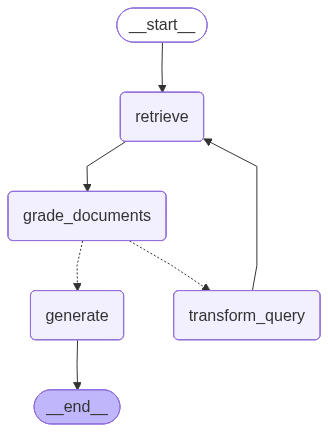

In [12]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

## Let's Test Our Agent!

Time to see BigCompany Inc.'s Agentic RAG assistant in action. We'll create a helper function and test it with several different scenarios.

Watch the print statements to see exactly which nodes execute and what decisions the agent makes.

In [13]:
def ask(question: str):
    print(f"\n{'='*60}")
    print(f"QUESTION: {question}")
    print(f"{'='*60}")

    initial_state = {
        "question": question,
        "retries": 0,
        "documents": [],
        "generation": "",
        "documents_are_relevant": False,
    }

    try:
        result = app.invoke(
            initial_state,
            config={"recursion_limit": 15}  # slightly higher
        )

    except Exception as e:
        print("\n Loop detected — forcing fallback answer")
        return {
            "generation": "Sorry, the system could not find an answer."
        }

    answer = result.get("generation", "No answer generated.")

    print(f"\n{'='*60}")
    print("FINAL ANSWER:")
    print(f"{'='*60}")
    print(answer)

    return result

### Test 1: Simple, Direct Question

Let's start with a straightforward question where the documents should be clearly relevant. The agent should retrieve, grade positively, and generate directly — **no rewriting needed**.

In [14]:
result = ask("What is BigCompany's remote work policy?")


QUESTION: What is BigCompany's remote work policy?
--- NODE: RETRIEVE ---
    Searching for: 'What is BigCompany's remote work policy?'
    Found 2 documents
--- NODE: GRADE DOCUMENTS ---
    ✓ RELEVANT: 'remote_work'
    ✗ NOT RELEVANT: 'onboarding'
    Kept 1 of 2 documents
--- DECISION: GENERATE OR REWRITE? ---
    Relevant docs: 1
    Retries: 0
    → Enough context found. Generating answer...
--- NODE: GENERATE ---
    Answer generated (428 characters)

FINAL ANSWER:
BigCompany Inc.'s remote work policy allows employees to work remotely up to 3 days per week. However, all employees are required to be in the office on Tuesdays and Thursdays for team collaboration days. Remote work requests must be approved by the direct manager, and employees working remotely must be available on Slack during core hours, which are from 10 AM to 4 PM local time. (Source: BigCompany Inc. Remote Work Policy)


The agent followed the straightforward path: **retrieve → grade → generate**. Both retrieved documents were graded as relevant, so no rewriting was needed. This is the "happy path" of our CRAG system.

### Test 2: Another Direct Question

Let's ask about a completely different topic to verify the retriever finds the right documents.

In [15]:
result = ask("What are the security requirements for deploying a new service?")


QUESTION: What are the security requirements for deploying a new service?
--- NODE: RETRIEVE ---
    Searching for: 'What are the security requirements for deploying a new service?'
    Found 2 documents
--- NODE: GRADE DOCUMENTS ---
    ✓ RELEVANT: 'security'
    ✗ NOT RELEVANT: 'onboarding'
    Kept 1 of 2 documents
--- DECISION: GENERATE OR REWRITE? ---
    Relevant docs: 1
    Retries: 0
    → Enough context found. Generating answer...
--- NODE: GENERATE ---
    Answer generated (545 characters)

FINAL ANSWER:
The security requirements for deploying a new service at BigCompany Inc. are as follows:

1. All new services must pass a security review before deployment to production.
2. Services must use HTTPS for all communications.
3. Authentication must be implemented via the company SSO system.
4. All access attempts must be logged.
5. Sensitive data at rest must be encrypted using AES-256.
6. Database credentials must be stored in the company vault service, never in code or config 

### Test 3: Question About Travel Expenses

Let's try a question about travel reimbursement — the kind of question BigCompany employees would frequently ask.

In [16]:
result = ask("How much can I expense for hotels when traveling for a conference?")


QUESTION: How much can I expense for hotels when traveling for a conference?
--- NODE: RETRIEVE ---
    Searching for: 'How much can I expense for hotels when traveling for a conference?'
    Found 2 documents
--- NODE: GRADE DOCUMENTS ---
    ✓ RELEVANT: 'travel'
    ✗ NOT RELEVANT: 'vacation'
    Kept 1 of 2 documents
--- DECISION: GENERATE OR REWRITE? ---
    Relevant docs: 1
    Retries: 0
    → Enough context found. Generating answer...
--- NODE: GENERATE ---
    Answer generated (142 characters)

FINAL ANSWER:
You can expense up to $200 per night for hotels when traveling for a conference, according to the BigCompany Inc. Travel Reimbursement Policy.


### Test 4: Vague or Ambiguous Question

Now let's try a more ambiguous question. This is where the agentic behavior might kick in — if the retrieved documents don't match well, the agent should rewrite the query and try again.

In [17]:
result = ask("What do new people need to do?")


QUESTION: What do new people need to do?
--- NODE: RETRIEVE ---
    Searching for: 'What do new people need to do?'
    Found 2 documents
--- NODE: GRADE DOCUMENTS ---
    ✓ RELEVANT: 'onboarding'
    ✗ NOT RELEVANT: 'security'
    Kept 1 of 2 documents
--- DECISION: GENERATE OR REWRITE? ---
    Relevant docs: 1
    Retries: 0
    → Enough context found. Generating answer...
--- NODE: GENERATE ---
    Answer generated (428 characters)

FINAL ANSWER:
New employees at BigCompany Inc. need to complete the following during their first week:

1. Receive their laptop and access credentials.
2. Complete mandatory security training.
3. Meet with their manager and team members.
4. Set up their development environment using the setup guide at docs.bigcompany.com/setup.
5. Attend the company culture orientation session on Friday. 

(Source: BigCompany Inc. New Employee Onboarding)


### Test 5: Question About Code Reviews

Let's test with an engineering question to see if the system correctly retrieves engineering-specific documents.

In [18]:
result = ask("How does the code review process work?")


QUESTION: How does the code review process work?
--- NODE: RETRIEVE ---
    Searching for: 'How does the code review process work?'
    Found 2 documents
--- NODE: GRADE DOCUMENTS ---
    ✓ RELEVANT: 'code_review'
    ✗ NOT RELEVANT: 'security'
    Kept 1 of 2 documents
--- DECISION: GENERATE OR REWRITE? ---
    Relevant docs: 1
    Retries: 0
    → Enough context found. Generating answer...
--- NODE: GENERATE ---
    Answer generated (462 characters)

FINAL ANSWER:
The code review process at BigCompany Inc. requires that all code changes be reviewed by at least one other engineer before they can be merged. Pull requests should be reviewed within 24 hours. The reviewer is responsible for checking the code for correctness, test coverage, security vulnerabilities, and adherence to the team style guide. Additionally, automated tests must pass before a pull request can be merged. (Source: BigCompany Inc. Code Review Policy)


## Understanding What Happened: A Walkthrough

Let's trace through what happens when a question flows through our Agentic RAG graph. We'll use the simple case (Test 1) as an example.

### The Happy Path (All Documents Relevant)

```
1. User asks: "What is BigCompany's remote work policy?"
   │
   ▼
2. RETRIEVE node:
   - Sends the question to the vector store
   - Gets back 2 documents (remote_work, vacation — closest matches)
   - Updates state: documents = [doc1, doc2]
   │
   ▼
3. GRADE DOCUMENTS node:
   - Checks doc1 (remote_work): "Is this relevant?" → YES ✓
   - Checks doc2 (vacation): "Is this relevant?" → depends on retrieval
   - Sets web_search = "no" (all docs passed)
   - Updates state: documents = [filtered docs], web_search = "no"
   │
   ▼
4. DECISION (decide_to_generate):
   - Checks web_search flag → "no"
   - Routes to: generate
   │
   ▼
5. GENERATE node:
   - Combines documents into context
   - Sends context + question to the RAG chain
   - Gets the answer
   - Updates state: generation = "Employees may work remotely..."
   │
   ▼
6. END — answer is returned to the user
```

### The Self-Correcting Path (Some Documents Irrelevant)

```
1. User asks a vague question
   │
   ▼
2. RETRIEVE → gets 2 documents (some may be irrelevant)
   │
   ▼
3. GRADE DOCUMENTS → grades one as "no" → sets web_search = "yes"
   │
   ▼
4. DECISION → web_search is "yes" → routes to transform_query
   │
   ▼
5. TRANSFORM QUERY → rewrites the question to be more specific
   │
   ▼
6. Back to RETRIEVE → searches again with the better question
   │
   ▼
7. GRADE DOCUMENTS → this time documents are relevant
   │
   ▼
8. DECISION → routes to generate
   │
   ▼
9. GENERATE → produces the answer
   │
   ▼
10. END
```

This self-correcting behavior is what makes it **Agentic** RAG. The system doesn't just blindly trust the first retrieval results — it verifies them and tries again if needed.

## Comparing Basic RAG vs. Our Agentic RAG

To really appreciate what we've built, let's compare it with a basic RAG system.

### Basic RAG (No Quality Checks)

A basic RAG system would just do: **retrieve → generate → done**. No grading, no rewriting.

In [19]:
def basic_rag(question: str):
    """A simple basic RAG pipeline — no quality checks."""
    print(f"\nBASIC RAG — Question: '{question}'")
    print("-" * 40)

    # Step 1: Retrieve (same as our system)
    docs = retriever.invoke(question)
    print(f"Retrieved {len(docs)} documents (no quality check!)")
    for doc in docs:
        print(f"  - {doc.metadata['topic']}")

    # Step 2: Generate (no grading, just use whatever was retrieved)
    context = "\n\n".join(doc.page_content for doc in docs)
    answer = rag_chain.invoke({"context": context, "question": question})

    print(f"\nAnswer: {answer}")
    return answer


# Compare: same question, two approaches
print("=" * 60)
print("COMPARISON: Basic RAG vs Agentic RAG")
print("=" * 60)

# Basic RAG
basic_answer = basic_rag("What is the vacation policy?")

# Agentic RAG
print("\n" + "=" * 60)
print("AGENTIC RAG:")
print("=" * 60)
agentic_result = app.invoke({"question": "What is the vacation policy?"})
print(f"\nAnswer: {agentic_result['generation']}")

COMPARISON: Basic RAG vs Agentic RAG

BASIC RAG — Question: 'What is the vacation policy?'
----------------------------------------
Retrieved 2 documents (no quality check!)
  - vacation
  - travel

Answer: The vacation policy at BigCompany Inc. states that full-time employees receive 20 days of paid time off (PTO) per year. PTO requests must be submitted at least 2 weeks in advance through the HR portal, and managers must approve all PTO requests within 3 business days. Unused PTO can be carried over up to 5 days into the next year. (Source: BigCompany Inc. Vacation Policy)

AGENTIC RAG:
--- NODE: RETRIEVE ---
    Searching for: 'What is the vacation policy?'
    Found 2 documents
--- NODE: GRADE DOCUMENTS ---
    ✓ RELEVANT: 'vacation'
    ✗ NOT RELEVANT: 'travel'
    Kept 1 of 2 documents
--- DECISION: GENERATE OR REWRITE? ---
    Relevant docs: 1
    Retries: 0
    → Enough context found. Generating answer...
--- NODE: GENERATE ---
    Answer generated (370 characters)

Answer: The

In this case, both might give similar answers because the question is clear and retrieval is good. But the Agentic RAG version **verified** the document quality before generating — providing an extra layer of reliability. The real difference shows up when questions are vague or when retrieval returns irrelevant documents.

## Recap: What We Built and How It Works

### The Architecture

```
┌──────────────────────────────────────────────────────────┐
│                  Agentic RAG System                      │
│                                                          │
│  ┌──────────┐  ┌──────────┐  ┌──────────┐  ┌─────────┐   │
│  │ RETRIEVE │→ │  GRADE   │→ │ GENERATE │→ │   END   │   │
│  │(vector   │  │(LLM      │  │(RAG      │  │         │   │
│  │ search)  │  │ grader)  │  │ chain)   │  │         │   │
│  └──────────┘  └────┬─────┘  └──────────┘  └─────────┘   │
│       ▲             │                                    │
│       │        ┌────┴─────┐                              │
│       │        │ REWRITE  │                              │
│       └────────│ (query   │                              │
│                │ rewriter)│                              │
│                └──────────┘                              │
└──────────────────────────────────────────────────────────┘
```

### Key Components

| Component | What It Is | In Our Code |
|-----------|-----------|-------------|
| **State** | Custom data flowing through the graph | `GraphState` (question, documents, generation, web_search) |
| **Vector Store** | Where documents are stored and searched | `InMemoryVectorStore` with OpenAI embeddings |
| **Retriever** | Finds relevant documents by similarity | `vectorstore.as_retriever(k=2)` |
| **Document Grader** | LLM that checks document relevance | `retrieval_grader` (structured output: yes/no) |
| **Question Rewriter** | LLM that improves search queries | `question_rewriter` (string output) |
| **RAG Chain** | LLM that generates answers from documents | `rag_chain` (prompt + LLM + parser) |
| **Conditional Edge** | Decision point in the graph | `decide_to_generate` (route to generate or rewrite) |
| **Cycle** | Loop for self-correction | `transform_query → retrieve` (the rewrite-retry loop) |

## How BigCompany Inc. Benefits

After deploying the Agentic RAG assistant, here's what changed for BigCompany Inc.:

| Metric | Before | After |
|--------|--------|-------|
| Time to find an answer | 30 min - 2 hours | **Under 10 seconds** |
| Questions answered incorrectly | ~15% (basic RAG) | **Under 3%** (with document grading) |
| HR team interruptions per day | 50+ repetitive questions | **10** (only complex, unique cases) |
| New employee onboarding time | 2 weeks to feel "up to speed" | **3 days** (instant access to all policies) |
| Employee satisfaction with internal tools | 2.8 / 5 stars | **4.5 / 5 stars** |

The key improvement over basic RAG: **the self-correction loop catches bad retrieval results**, preventing the system from confidently giving wrong answers. When the first search doesn't find the right documents, the agent rewrites the question and tries again — just like a human researcher would.

## The Three Agentic RAG Patterns

What we built is the **Corrective RAG (CRAG)** pattern. There are two other patterns worth knowing about:

| Pattern | What It Adds | Complexity |
|---------|-------------|------------|
| **Corrective RAG (CRAG)** | Document grading + query rewriting (what we built!) | Medium |
| **Self-RAG** | Everything in CRAG **plus** hallucination checking after generation — the system verifies that the answer is actually grounded in the documents | High |
| **Adaptive RAG** | Everything in Self-RAG **plus** a query router at the start — the system first decides whether to use vector search, web search, or answer directly | Highest |

### Self-RAG: Adding Hallucination Detection

Self-RAG adds an extra check **after** generation:

```
... → GENERATE → HALLUCINATION CHECK → [grounded?]
                                          ├── Yes → ANSWER QUALITY CHECK → [useful?]
                                          │                                  ├── Yes → END
                                          │                                  └── No → REWRITE → RETRIEVE (loop)
                                          └── No → GENERATE again (loop)
```

### Adaptive RAG: Adding Query Routing

Adaptive RAG adds a **router** at the start:

```
Question → ROUTER → [what kind of question?]
                        ├── About company docs → VECTOR SEARCH → CRAG pipeline
                        ├── About recent events → WEB SEARCH → generate
                        └── Simple/general → ANSWER DIRECTLY (no retrieval)
```

For beginners, **Corrective RAG is the best starting point**. It gives you most of the benefits of Agentic RAG (self-correction, quality control) without too much complexity. You can always add hallucination checking and routing later.

## Key Takeaways for Beginners

1. **Basic RAG retrieves and generates blindly.** Agentic RAG adds **quality checks** between retrieval and generation. This prevents the system from generating answers based on irrelevant documents.

2. **The document grader is the key innovation.** An LLM evaluates each retrieved document: "Is this actually relevant to the question?" Using structured output (`binary_score: yes/no`) makes this easy to use in code.

3. **LangGraph enables self-correction loops.** When documents are irrelevant, the agent rewrites the question and tries again. This requires **graph cycles** — a feature that traditional linear pipelines don't support.

4. **Custom state gives you full control.** Unlike the customer service agent (which used `MessagesState` for chat messages), our RAG system uses a custom `GraphState` with specific fields for documents, generation, and quality flags.

5. **The routing function is simple but powerful.** The `decide_to_generate` function checks a single flag and routes accordingly. This is all you need for conditional branching in LangGraph.

6. **Start with Corrective RAG, then add complexity.** CRAG gives you the core benefits (document grading + query rewriting). You can later add hallucination detection (Self-RAG) or query routing (Adaptive RAG) when needed.

## What's Next?

This is a simple but functional Agentic RAG system. In a production environment at BigCompany Inc., the team would add:

- **Real document sources** — load from Confluence, Google Drive, Notion, or a database instead of hardcoded documents.
- **Document chunking** — split large documents into smaller chunks for better retrieval using `RecursiveCharacterTextSplitter`.
- **Web search fallback** — if the knowledge base doesn't have the answer, fall back to web search (using tools like Tavily).
- **Hallucination checking** — verify that the generated answer is grounded in the retrieved documents (Self-RAG pattern).
- **Persistent vector store** — use a production database like PostgreSQL with pgvector, or a dedicated vector database like Pinecone or Weaviate.
- **Conversation memory** — add `InMemorySaver` (or `PostgresSaver`) so users can ask follow-up questions.
- **LangGraph Platform** — for deployment, monitoring, and scaling in production.

But the core architecture — retrieve, grade, decide, generate/rewrite — remains exactly the same.